In [1]:
import pandas as pd

df = pd.read_csv('C:\\Users\\ARPIT DIMRI\\OneDrive\\Desktop\\Premiere-League-pred-model\\data\\processed_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [2]:
#Home teamm features
df['home_goals_avg'] = df.groupby('Home')['HomeGoals'].transform(lambda x: x.shift(1).rolling(5,min_periods=1).mean())
df['home_conceded_avg'] = df.groupby('Home')['AwayGoals'].transform(lambda x: x.shift(1).rolling(5,min_periods=1).mean())

In [13]:
#Away team features
df['away_goals_avg'] = df.groupby('Away')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)#Away team features
df['away_conceded_avg'] = df.groupby('Away')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)


In [14]:
print((df['away_goals_avg'] == df['away_conceded_avg']).all())

False


In [15]:
df.head()

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR,result,home_goals_avg,...,home_goal_diff,away_goal_diff,strength_diff,attack_diff,defense_diff,abs_strength_diff,abs_attack_diff,abs_defense_diff,expected_total_goals_proxy,expected_total_conceded_proxy
22,1993,3,1992-08-22,Norwich City,1,1,Everton,D,Draw,2.0,...,1.0,0.0,1.0,-1.0,-2.0,1.0,1.0,2.0,5.0,4.0
23,1993,3,1992-08-22,Sheffield Weds,3,3,Chelsea,D,Draw,2.0,...,2.0,0.0,2.0,1.0,-1.0,2.0,1.0,1.0,3.0,1.0
24,1993,3,1992-08-22,Tottenham,2,2,Crystal Palace,D,Draw,0.0,...,-2.0,0.0,-2.0,-1.0,1.0,2.0,1.0,1.0,1.0,3.0
25,1993,3,1992-08-22,Blackburn,1,0,Manchester City,H,Home Win,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
26,1993,3,1992-08-22,Wimbledon,1,2,Coventry City,A,Away Win,0.0,...,-1.0,0.0,-1.0,-2.0,-1.0,1.0,2.0,1.0,2.0,3.0


Text(0.5, 1.0, 'Away Goal Difference vs Away Goals')

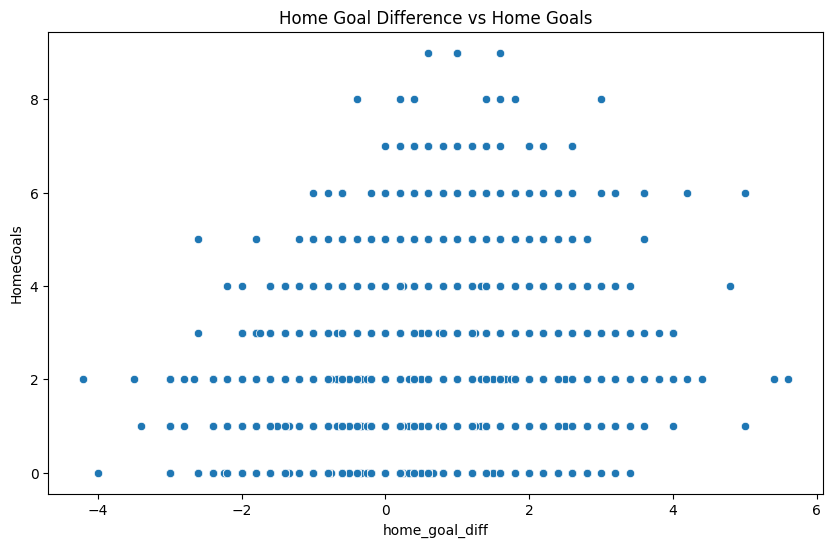

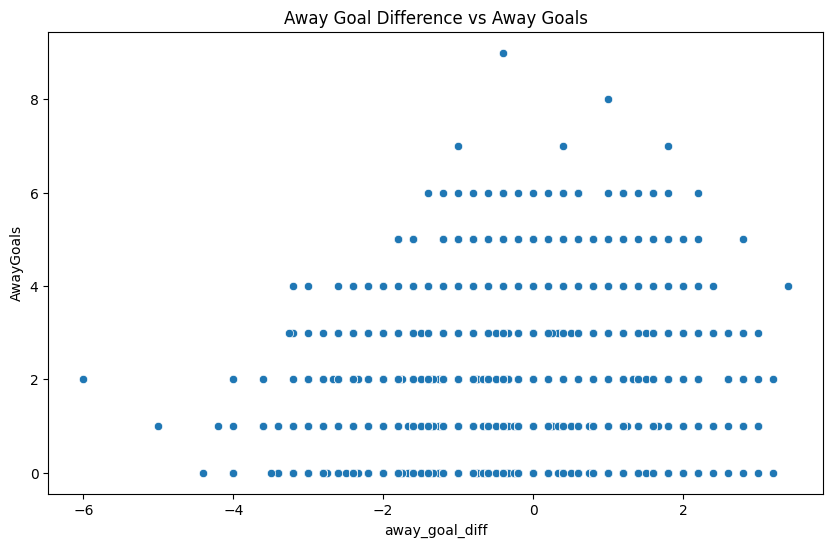

In [16]:
#more impactfull features

df['home_goal_diff'] = df['home_goals_avg'] - df['home_conceded_avg']
df['away_goal_diff'] = df['away_goals_avg']  - df['away_conceded_avg']

df['strength_diff'] = df['home_goal_diff'] - df['away_goal_diff']
df['attack_diff'] = df['home_goals_avg'] - df['away_conceded_avg']
df['defense_diff'] = df['home_conceded_avg'] - df['away_goals_avg']

df['abs_strength_diff'] = abs(df['strength_diff'])
df['abs_attack_diff'] = abs(df['attack_diff'])
df['abs_defense_diff'] = abs(df['defense_diff'])

df['expected_total_goals_proxy'] = df['home_goals_avg'] + df['away_goals_avg']
df['expected_total_conceded_proxy'] = df['home_conceded_avg'] + df['away_conceded_avg']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='home_goal_diff', y='HomeGoals', data=df)
plt.title('Home Goal Difference vs Home Goals')

plt.figure(figsize = (10,6))
sns.scatterplot(x='away_goal_diff', y='AwayGoals', data=df)
plt.title('Away Goal Difference vs Away Goals')






In [17]:
df.dropna(inplace=True)

In [18]:
df.head(15)


,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR,result,home_goals_avg,...,home_goal_diff,away_goal_diff,strength_diff,attack_diff,defense_diff,abs_strength_diff,abs_attack_diff,abs_defense_diff,expected_total_goals_proxy,expected_total_conceded_proxy
43,1993,5,1992-08-29,Crystal Palace,1,2,Norwich City,A,Away Win,2.0,...,0.0,-2.0,2.0,-1.0,1.0,2.0,1.0,1.0,3.0,5.0
44,1993,5,1992-08-29,Nott'ham Forest,0,2,Manchester Utd,A,Away Win,1.0,...,1.0,1.0,0.0,1.0,-1.0,0.0,1.0,1.0,2.0,0.0
45,1993,5,1992-08-29,Manchester City,3,3,Oldham Athletic,D,Draw,2.0,...,1.0,-2.0,3.0,0.0,1.0,3.0,0.0,1.0,2.0,3.0
46,1993,5,1992-08-29,Sheffield Utd,0,2,Aston Villa,A,Away Win,2.0,...,0.5,-1.0,1.5,1.0,1.5,1.5,1.0,1.5,2.0,2.5
48,1993,5,1992-08-29,Everton,0,0,Wimbledon,D,Draw,1.0,...,0.5,0.0,0.5,-1.0,-1.5,0.5,1.0,1.5,3.0,2.5
49,1993,5,1992-08-29,Coventry City,0,2,Blackburn,A,Away Win,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
50,1993,5,1992-08-29,Arsenal,2,1,Sheffield Weds,H,Home Win,2.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,3.0,3.0
51,1993,5,1992-08-29,Chelsea,1,0,QPR,H,Home Win,0.5,...,0.0,1.0,-1.0,0.5,-0.5,1.0,0.5,0.5,1.5,0.5
52,1993,5,1992-08-29,Leeds United,2,2,Liverpool,D,Draw,3.5,...,3.0,0.0,3.0,1.5,-1.5,3.0,1.5,1.5,5.5,2.5
53,1993,5,1992-08-30,Ipswich Town,1,1,Tottenham,D,Draw,1.5,...,0.0,-5.0,5.0,-3.5,1.5,5.0,3.5,1.5,1.5,6.5


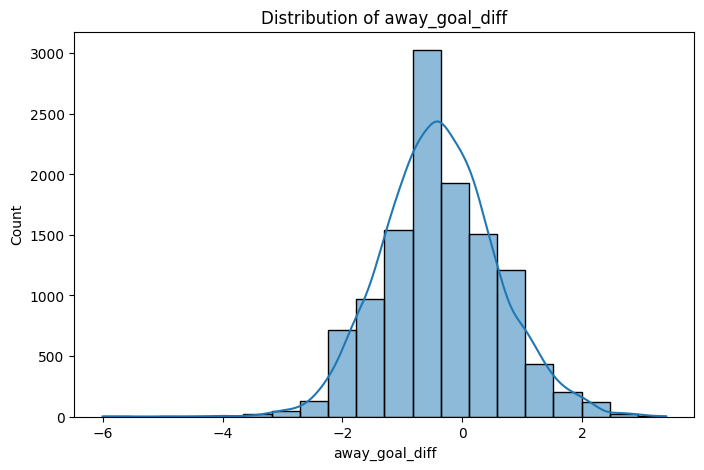

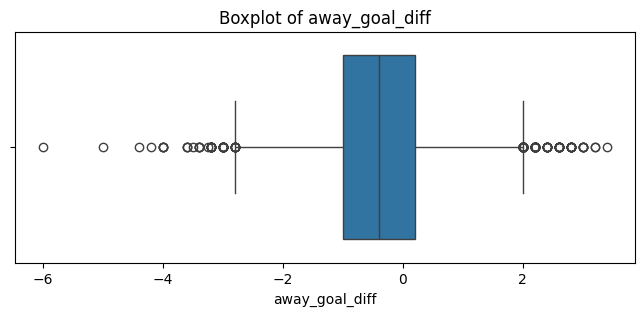

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['away_goal_diff'], bins=20, kde=True)
plt.title("Distribution of away_goal_diff")
plt.xlabel("away_goal_diff")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=df['away_goal_diff'])
plt.title("Boxplot of away_goal_diff")
plt.xlabel("away_goal_diff")
plt.show()


In [20]:
print(df['away_goal_diff'].value_counts().sort_index().head(20))
print("Zero count:", (df['away_goal_diff'] == 0).sum())
print("Zero percentage:", ((df['away_goal_diff'] == 0).mean() * 100).round(2), "%")

away_goal_diff
-6.000000     1
-5.000000     1
-4.400000     1
-4.200000     1
-4.000000     4
-3.600000     1
-3.600000     1
-3.600000     1
-3.500000     1
-3.400000     4
-3.250000     1
-3.200000     9
-3.200000     4
-3.000000    23
-2.800000     9
-2.800000    16
-2.750000     1
-2.666667     1
-2.600000    30
-2.600000    12
Name: count, dtype: int64
Zero count: 932
Zero percentage: 7.83 %


In [21]:
df.to_csv("C:\\Users\\ARPIT DIMRI\\OneDrive\\Desktop\\Premiere-League-pred-model\\data\\features.csv", index=False)
print("features.csv saved successfully!")

features.csv saved successfully!


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11898 entries, 43 to 12025
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Season_End_Year                11898 non-null  int64         
 1   Wk                             11898 non-null  int64         
 2   Date                           11898 non-null  datetime64[ns]
 3   Home                           11898 non-null  object        
 4   HomeGoals                      11898 non-null  int64         
 5   AwayGoals                      11898 non-null  int64         
 6   Away                           11898 non-null  object        
 7   FTR                            11898 non-null  object        
 8   result                         11898 non-null  object        
 9   home_goals_avg                 11898 non-null  float64       
 10  home_conceded_avg              11898 non-null  float64       
 11  away_goals_avg     

result
Away Win   -0.129926
Draw       -0.356955
Home Win   -0.540854
Name: away_goal_diff, dtype: float64


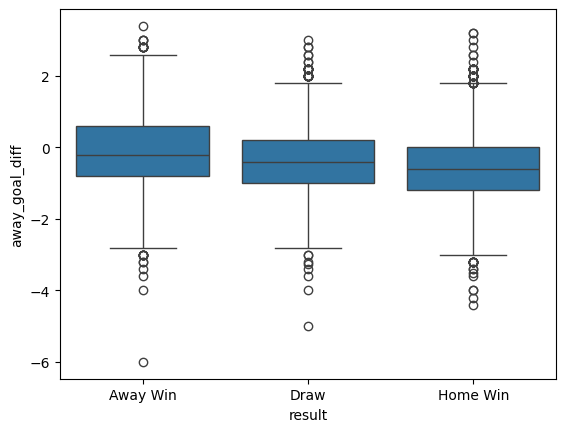

In [27]:
print(df.groupby('result')['away_goal_diff'].mean())
sns.boxplot(x='result', y='away_goal_diff', data=df)
plt.show()

In [24]:
print(df[['Away', 'away_goals_avg', 'away_conceded_avg', 'away_goal_diff']].head(20))

               Away  away_goals_avg  away_conceded_avg  away_goal_diff
0      Norwich City             1.0                3.0            -2.0
1    Manchester Utd             1.0                0.0             1.0
2   Oldham Athletic             0.0                2.0            -2.0
3       Aston Villa             0.0                1.0            -1.0
4         Wimbledon             2.0                2.0             0.0
5         Blackburn             0.0                0.0             0.0
6    Sheffield Weds             1.0                1.0             0.0
7               QPR             1.0                0.0             1.0
8         Liverpool             2.0                2.0             0.0
9         Tottenham             0.0                5.0            -5.0
10  Nott'ham Forest             3.0                5.0            -2.0
11     Ipswich Town             1.0                1.0             0.0
12  Manchester City             0.0                1.0            -1.0
13    

In [25]:
print(df['away_goal_diff'].describe())
print("Zero count:", (df['away_goal_diff'] == 0).sum())
print("Zero percentage:", ((df['away_goal_diff'] == 0).mean() * 100).round(2), "%")

count    11898.000000
mean        -0.376821
std          0.953766
min         -6.000000
25%         -1.000000
50%         -0.400000
75%          0.200000
max          3.400000
Name: away_goal_diff, dtype: float64
Zero count: 932
Zero percentage: 7.83 %


In [26]:
print(df[['away_goal_diff', 'result_encoded']].corr())

KeyError: "['result_encoded'] not in index"